In [116]:
pip install yfinance

In [117]:
!pip install tensorflow

In [10]:
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [11]:
# 从今天起往前推42天，然后再往前推5年
end_date = datetime.today() - timedelta(days=0)
start_date = end_date - timedelta(days=365 * 5)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "601319.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")

import pandas as pd

pf = pd.read_csv("recent_stock_prices.csv")
print(pf.head())

# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")

/tmp/ipython-input-2506584446.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv（从 2020-09-03 到 2025-09-02）
        Price              Close                High                Low  \
0      Ticker          601319.SS           601319.SS          601319.SS   
1        Date                NaN                 NaN                NaN   
2  2020-09-03   6.22231912612915  6.2831520054927354  6.213628951585831   
3  2020-09-04  6.152795314788818  6.1875568374629895  6.135414553451733   
4  2020-09-07  6.091962814331055   6.204937555030163  6.091962814331055   

                Open     Volume  
0          601319.SS  601319.SS  
1                NaN        NaN  
2  6.248390478539283   36839725  
3  6.170176076125904   48773940  
4  6.126724336760017   46385699  
CSV 数据预览：
        Price              Close                High                Low  \
0      Ticker          601319.SS           601319.SS          601319.SS   
1        Date                NaN                 NaN                NaN   
2  2020-09-03   6.22231912612915  6.2831520054927354

In [12]:

# 读取原始 CSV
df = pd.read_csv('recent_stock_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv('cleaned_stock_data.csv', index=False)
# 显示最后五行数据
print(df.tail())


           Date  Close  High   Low  Open       Volume
1206 2025-08-26   8.74  8.84  8.73  8.80   64796432.0
1207 2025-08-27   8.52  8.77  8.51  8.73   86534083.0
1208 2025-08-28   8.71  8.73  8.47  8.51  102959961.0
1209 2025-08-29   8.98  9.27  8.75  8.75  158453506.0
1210 2025-09-01   8.75  8.95  8.72  8.92  102162899.0


In [121]:
# 设置窗口大小和预测偏移
window_size = 60        # 用过去 50 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价


In [34]:
# 加载你的数据（假设 CSV 文件中包含 Date 和 Close 列）
df = pd.read_csv('cleaned_stock_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 计算 MACD 和信号线
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    return df

# 计算 RSI 指标
def compute_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

# 添加技术指标
def add_technical_indicators(df):
    df = compute_macd(df)
    df = compute_rsi(df)
    df.dropna(inplace=True)
    return df

# 应用技术指标
df = add_technical_indicators(df)


In [35]:
# Add cyclical time features
df['Day_sin'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['Day_cos'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['Month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

print(df.head())

         Date     Close      High       Low      Open      Volume  EMA_fast  \
13 2020-09-22  5.996368  6.144105  5.978988  6.039820  53065607.0  6.062831   
14 2020-09-23  5.961607  6.022439  5.944226  5.996369  35923390.0  6.047258   
15 2020-09-24  5.944226  6.013749  5.918155  5.926846  38618852.0  6.031407   
16 2020-09-25  5.952917  5.978988  5.892084  5.926846  34583640.0  6.019331   
17 2020-09-28  5.926846  5.978988  5.918155  5.935536  25713691.0  6.005103   

    EMA_slow      MACD  MACD_signal        RSI   Day_sin   Day_cos  Month_sin  \
13  6.112913 -0.050083    -0.045995  40.579699 -0.991114 -0.133015       -1.0   
14  6.101706 -0.054448    -0.047686  39.436615 -0.993257 -0.115935       -1.0   
15  6.090040 -0.058634    -0.049875  41.176490 -0.995105 -0.098820       -1.0   
16  6.079883 -0.060552    -0.052011  43.846161 -0.996659 -0.081676       -1.0   
17  6.068547 -0.063444    -0.054297  36.134472 -0.999546 -0.030120       -1.0   

       Month_cos  
13 -1.836970e-16  


In [125]:
# 模型预测
y_pred = model.predict(X_val)

# 反归一化（只对 'Close' 一列）
y_val_rescaled = scaler.inverse_transform(
    np.concatenate([y_val.reshape(-1, 1), np.zeros((len(y_val), len(features)-1))], axis=1)
)[:, 0]

y_pred_rescaled = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
)[:, 0]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [37]:
print(df.head())

         Date     Close      High       Low      Open      Volume  EMA_fast  \
13 2020-09-22  5.996368  6.144105  5.978988  6.039820  53065607.0  6.062831   
14 2020-09-23  5.961607  6.022439  5.944226  5.996369  35923390.0  6.047258   
15 2020-09-24  5.944226  6.013749  5.918155  5.926846  38618852.0  6.031407   
16 2020-09-25  5.952917  5.978988  5.892084  5.926846  34583640.0  6.019331   
17 2020-09-28  5.926846  5.978988  5.918155  5.935536  25713691.0  6.005103   

    EMA_slow      MACD  MACD_signal        RSI   Day_sin   Day_cos  Month_sin  \
13  6.112913 -0.050083    -0.045995  40.579699 -0.991114 -0.133015       -1.0   
14  6.101706 -0.054448    -0.047686  39.436615 -0.993257 -0.115935       -1.0   
15  6.090040 -0.058634    -0.049875  41.176490 -0.995105 -0.098820       -1.0   
16  6.079883 -0.060552    -0.052011  43.846161 -0.996659 -0.081676       -1.0   
17  6.068547 -0.063444    -0.054297  36.134472 -0.999546 -0.030120       -1.0   

       Month_cos  
13 -1.836970e-16  


In [38]:
def run_lstm_pipeline(df, features, window_size, target_shift=1):
    # ...原始代码保持不变...

    # 最后加上返回
    return model, scaler

features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']
# result_df = evaluate_lstm_windows(df, features)

In [41]:
# 1️⃣ 加载并处理数据
df = pd.read_csv('cleaned_stock_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df = add_technical_indicators(df)

# 2️⃣ 添加周期性编码（可选）
df['Day_sin'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['Day_cos'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['Month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

# 3️⃣ 定义特征
features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']

# 4️⃣ 训练或评估
result_df = evaluate_lstm_windows(df, features)
print(result_df)



📊 正在评估窗口大小：30 天


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

📊 正在评估窗口大小：60 天


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

📊 正在评估窗口大小：90 天


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
   Window_Size       MAE       MSE      RMSE
0           30  1.430933  2.428229  1.558278
1           60  1.084472  1.487946  1.219814
2           90  1.212039  1.783950  1.335646


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def evaluate_lstm_windows(df, features, window_list=[30, 60, 90], target_shift=1):
    results = []

    for window_size in window_list:
        print(f"\n📊 正在评估窗口大小：{window_size} 天")

        # 数据归一化
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df[features])

        # 构建训练数据
        X, y = [], []
        for i in range(window_size, len(scaled_data) - target_shift):
            X.append(scaled_data[i - window_size:i])
            y.append(scaled_data[i + target_shift][0])  # 预测收盘价
        X, y = np.array(X), np.array(y)

        # 划分训练集和验证集
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

        # 构建模型
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
            Dropout(0.2),
            LSTM(32),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=0)

        # 模型预测
        y_pred = model.predict(X_val)

        # 反归一化
        y_val_rescaled = scaler.inverse_transform(
            np.concatenate([y_val.reshape(-1, 1), np.zeros((len(y_val), len(features)-1))], axis=1)
        )[:, 0]
        y_pred_rescaled = scaler.inverse_transform(
            np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
        )[:, 0]

        # 计算误差指标
        mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)
        mse = mean_squared_error(y_val_rescaled, y_pred_rescaled)
        rmse = np.sqrt(mse)

        results.append({
            'Window_Size': window_size,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse
        })

    result_df = pd.DataFrame(results)
    return result_df

    plt.show()


In [40]:
# 运行多个窗口大小测试
for window in [30, 60, 90]:
    print(f"\n正在测试窗口大小：{window} 天")
    run_lstm_pipeline(df, features, window_size=window)

features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']
result_df = evaluate_lstm_windows(df, features)




正在测试窗口大小：30 天


NameError: name 'model' is not defined

In [25]:
def predict_future_prices(model, df, features, scaler, window_size=90, days_ahead=10):
    recent_data = df[features].tail(window_size).copy()
    future_predictions = []

    for _ in range(days_ahead):
        # 归一化最近窗口
        scaled_window = scaler.transform(recent_data)
        X_input = scaled_window.reshape(1, window_size, len(features))

        # 预测下一天
        pred_scaled = model.predict(X_input)

        # 反归一化
        pred_full = np.concatenate([pred_scaled, np.zeros((1, len(features)-1))], axis=1)
        pred_unscaled = scaler.inverse_transform(pred_full)[0][0]
        future_predictions.append(pred_unscaled)

        # 构造下一窗口：移除最早一天，加入预测值
        new_row = recent_data.iloc[-1].copy()
        new_row['Close'] = pred_unscaled
        recent_data = pd.concat([recent_data.iloc[1:], pd.DataFrame([new_row])], ignore_index=True)

    return future_predictions


In [29]:
future_prices = predict_future_prices(model, df, features, scaler, window_size=90, days_ahead=10)

# 可视化
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), future_prices, marker='o', color='green')
plt.title('未来10天收盘价预测（基于90天窗口）')
plt.xlabel('未来第N天')
plt.ylabel('预测收盘价')
plt.grid(True)
plt.show()


NameError: name 'model' is not defined

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def predict_future_prices(model, df, features, scaler, window_size, days_ahead=10):
    recent_data = df[features].tail(window_size).copy()
    future_predictions = []

    for _ in range(days_ahead):
        # 归一化最近窗口
        scaled_window = scaler.transform(recent_data)
        X_input = scaled_window.reshape(1, window_size, len(features))

        # 预测下一天
        pred_scaled = model.predict(X_input)

        # 反归一化
        pred_full = np.concatenate([pred_scaled, np.zeros((1, len(features)-1))], axis=1)
        pred_unscaled = scaler.inverse_transform(pred_full)[0][0]
        future_predictions.append(pred_unscaled)

        # 构造下一窗口：移除最早一天，加入预测值
        new_row = recent_data.iloc[-1].copy()
        new_row['Close'] = pred_unscaled
        recent_data = pd.concat([recent_data.iloc[1:], pd.DataFrame([new_row])], ignore_index=True)

    return future_predictions

# 🔁 多窗口预测
window_sizes = [30, 60, 90]
predictions_dict = {}

for ws in window_sizes:
    preds = predict_future_prices(model, df, features, scaler, window_size=ws, days_ahead=10)
    predictions_dict[f"{ws}天窗口"] = preds

# 📊 可视化所有预测结果
plt.figure(figsize=(12, 6))
for label, preds in predictions_dict.items():
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 11), preds, marker='o', color='green')
    plt.title(f'{label}的未来10天收盘价预测')
    plt.xlabel('未来第N天')
    plt.ylabel('预测收盘价')



NameError: name 'model' is not defined

📊 不同窗口大小下的模型误差对比：
   Window_Size       MAE       MSE      RMSE
0           30  1.592693  3.856789  1.963871
1           60  1.334539  2.720942  1.649528
2           90  1.909723  4.604957  2.145916


/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2895817370.py:25: UserWarning: Glyph 65289 (\N{FULLWIDTH 

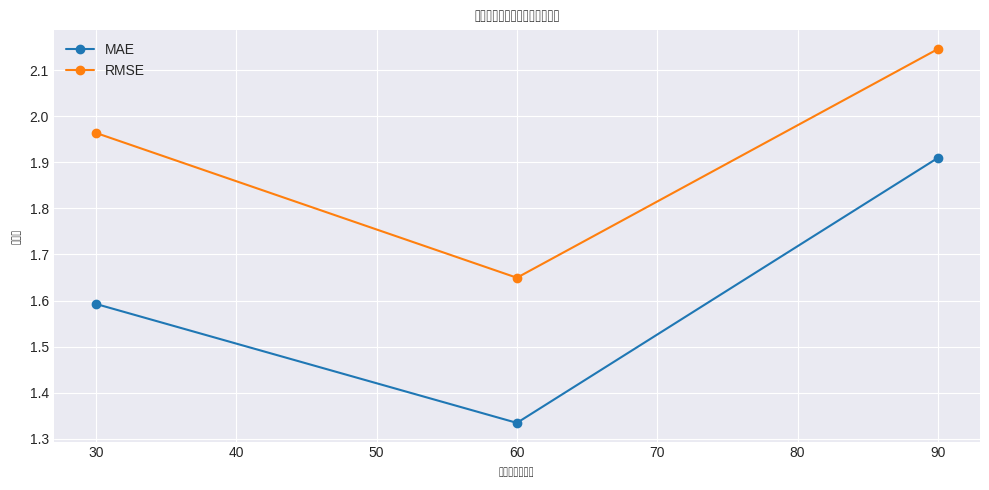

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 构建误差结果表
result_df = pd.DataFrame({
    'Window_Size': [30, 60, 90],
    'MAE': [1.592693, 1.334539, 1.909723],
    'MSE': [3.856789, 2.720942, 4.604957],
    'RMSE': [1.963871, 1.649528, 2.145916]
})

# 打印结果
print("📊 不同窗口大小下的模型误差对比：")
print(result_df)

# 可视化误差趋势
plt.figure(figsize=(10, 5))
plt.plot(result_df['Window_Size'], result_df['MAE'], marker='o', label='MAE')
plt.plot(result_df['Window_Size'], result_df['RMSE'], marker='o', label='RMSE')
plt.title('不同窗口大小下的误差指标对比')
plt.xlabel('窗口大小（天）')
plt.ylabel('误差值')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# 🗓️ 设置起始日期为 2025-07-30
start_date = datetime(2025, 7, 30)
end_date = start_date + timedelta(days=14)

# 📅 格式化为字符串（yfinance要求的格式）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 📈 下载江西铜业（601319.SS）的股票数据
ticker = "601319.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 💾 保存为 CSV 文件
csv_path = 'gap_check_prices.csv'
data.to_csv(csv_path)
print(f"✅ 数据已保存到 {csv_path}（从 {start_str} 到 {end_str}）")

# 📂 加载并预览数据
try:
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    print("📊 数据预览：")
    print(df)
except pd.errors.EmptyDataError:
    print("⚠️ CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("❌ 文件不存在，请确认文件路径是否正确。")



/tmp/ipython-input-2156679123.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

✅ 数据已保存到 gap_check_prices.csv（从 2025-07-30 到 2025-08-13）


KeyError: 'Date'

In [ ]:
# 读取原始 CSV
df = pd.read_csv('gap_check_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv('davi_stock_data.csv', index=False)
print(df)

        Date     Close      High       Low      Open       Volume
0 2025-07-30  8.450204  8.499505  8.351602  8.400904  103220332.0
1 2025-07-31  8.065657  8.420624  8.016355  8.420624  158477328.0
2 2025-08-01  8.045936  8.154399  8.036075  8.045936   75090850.0
3 2025-08-04  8.075516  8.095237  8.006495  8.026215   44914919.0
4 2025-08-05  8.282580  8.282580  8.065656  8.085376   85032844.0
5 2025-08-06  8.322021  8.381183  8.262861  8.282581   59200323.0
6 2025-08-07  8.253000  8.361462  8.183979  8.322021   58366450.0
7 2025-08-08  8.260000  8.330000  8.230000  8.300000   48879500.0
8 2025-08-11  8.170000  8.320000  8.160000  8.270000   76467429.0
9 2025-08-12  8.290000  8.300000  8.150000  8.170000   64172532.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Liberatio

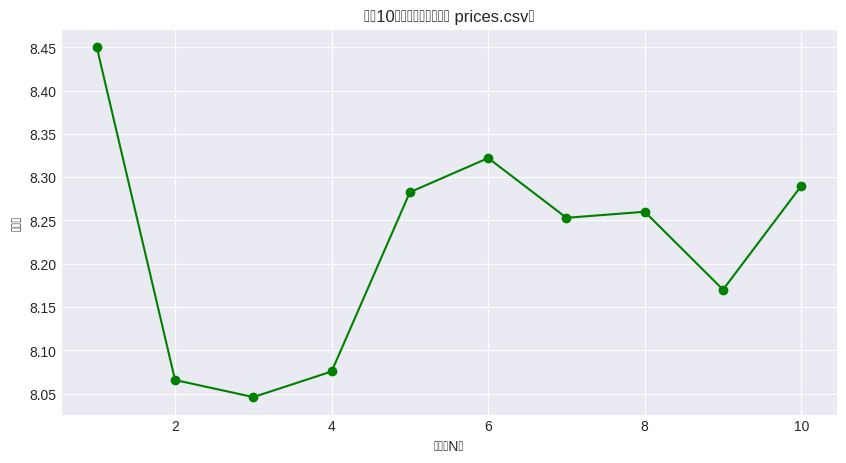

In [ ]:
# 读取 CSV 文件
df = pd.read_csv('davi_stock_data.csv')

# 取最近10天的收盘价
recent_prices = df['Close'].tail(10).values

# 绘图
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), recent_prices, marker='o', color='green')
plt.title('最近10天收盘价走势（来自 prices.csv）')
plt.xlabel('最近第N天')
plt.ylabel('收盘价')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 读取实际价格
actual_df = pd.read_csv('davi_stock_data.csv')
actual_prices = actual_df['Close'].tail(10).values

# 假设你已经有预测结果列表：future_predictions
# 比如：future_predictions = [8.45, 8.30, ..., 8.28]

# 构建对比表格
comparison_df = pd.DataFrame({
    '天数': range(1, 11),
    '实际收盘价': actual_prices,
    '预测收盘价': future_predictions,
    '误差': np.round(np.array(future_predictions) - np.array(actual_prices), 4)
})

print("\n📊 实际 vs 预测 收盘价对比（未来10天）")
print(comparison_df.to_string(index=False))


NameError: name 'future_predictions' is not defined

In [ ]:
# 获取最近10天的实际收盘价
actual_prices = df['Close'].tail(10).values

# 获取未来10天的预测收盘价（基于90天窗口）
future_predictions = predict_future_prices(model, df, features, scaler, window_size=90, days_ahead=10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-133068271.py:28: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOG

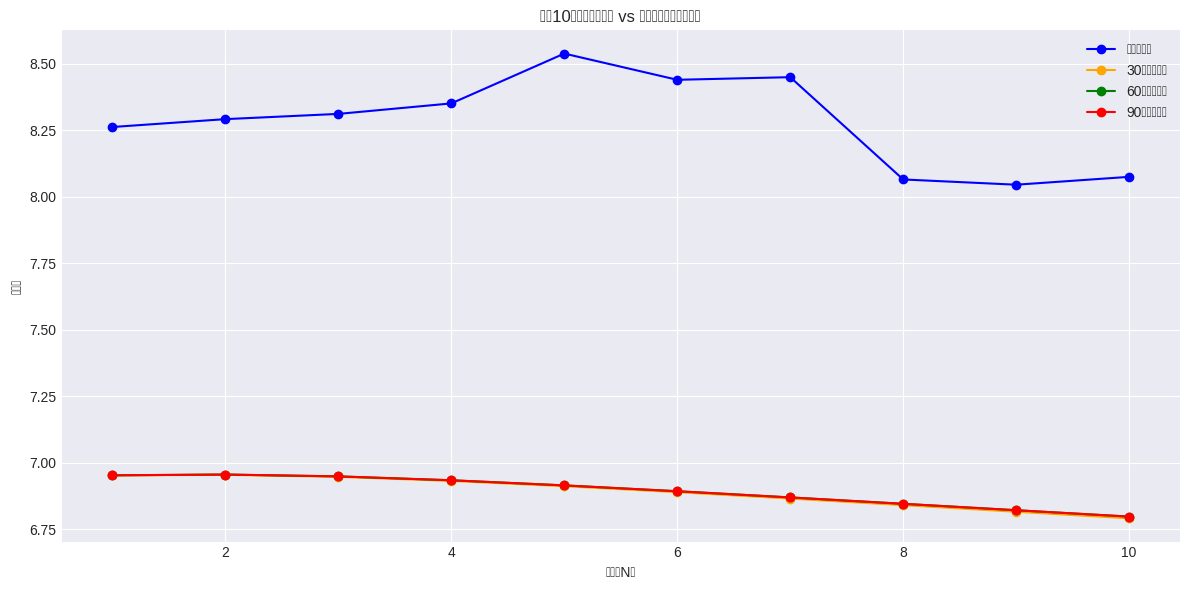

In [ ]:
import matplotlib.pyplot as plt

# 获取最近10天的实际收盘价
actual_prices = df['Close'].tail(10).values

# 生成不同窗口长度的预测结果
window_sizes = [30, 60, 90]
predictions_dict = {}

for ws in window_sizes:
    preds = predict_future_prices(model, df, features, scaler, window_size=ws, days_ahead=10)
    predictions_dict[f"{ws}天窗口"] = preds

# 📊 可视化：实际 vs 多窗口预测
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), actual_prices, label='实际收盘价', marker='o', color='blue')

# 添加每个窗口的预测曲线
colors = ['orange', 'green', 'red']
for (label, preds), color in zip(predictions_dict.items(), colors):
    plt.plot(range(1, 11), preds, label=f'{label}预测', marker='o', color=color)

plt.title('未来10天收盘价：实际 vs 预测（基于不同窗口）')
plt.xlabel('未来第N天')
plt.ylabel('收盘价')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 获取最近10天的实际收盘价
actual_prices = df['Close'].tail(10).values

# 获取未来10天的预测收盘价（分别基于30天、60天、90天窗口）
pred_30 = predict_future_prices(model, df, features, scaler, window_size=30, days_ahead=10)
pred_60 = predict_future_prices(model, df, features, scaler, window_size=60, days_ahead=10)
pred_90 = predict_future_prices(model, df, features, scaler, window_size=90, days_ahead=10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-52919536.py:14: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4E

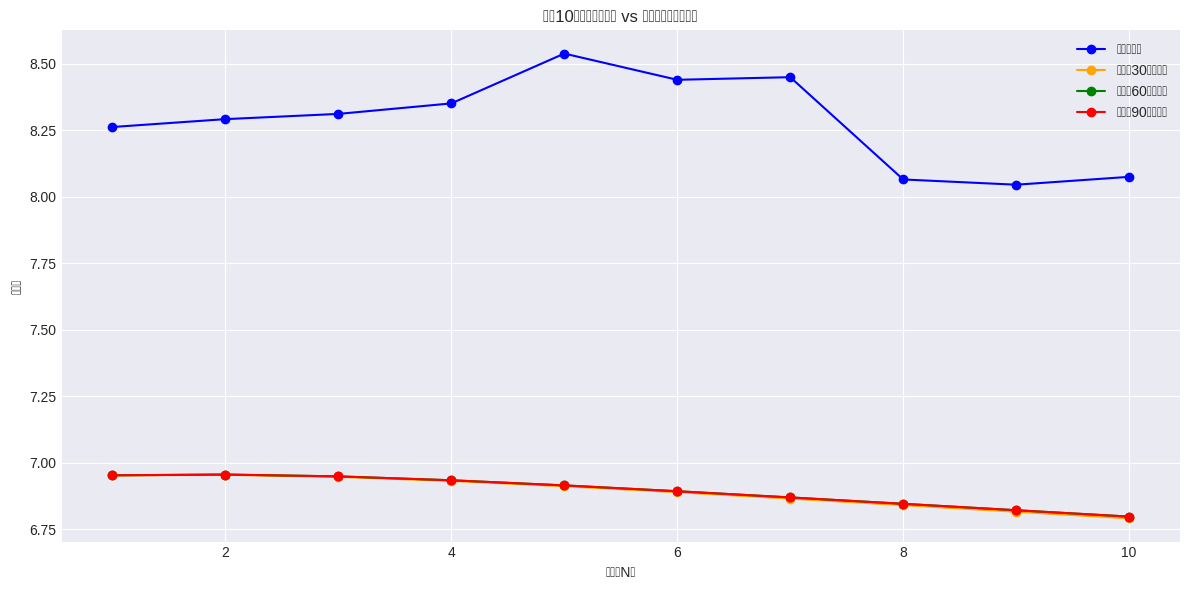

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), actual_prices, label='实际收盘价', marker='o', color='blue')
plt.plot(range(1, 11), pred_30, label='预测（30天窗口）', marker='o', color='orange')
plt.plot(range(1, 11), pred_60, label='预测（60天窗口）', marker='o', color='green')
plt.plot(range(1, 11), pred_90, label='预测（90天窗口）', marker='o', color='red')

plt.title('未来10天收盘价：实际 vs 预测（多窗口对比）')
plt.xlabel('未来第N天')
plt.ylabel('收盘价')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


这段代码循环遍历不同的窗口大小（30、60 和 90 天），并对每个窗口大小执行以下操作：

1.  打印当前正在测试的窗口大小。
2.  调用 `run_lstm_pipeline` 函数，传入数据框 `df`、特征列表 `features` 和当前的 `window_size`。这个函数负责构建、训练和评估 LSTM 模型，并绘制实际收盘价与预测收盘价的对比图。
3.  调用 `evaluate_lstm_windows` 函数（此函数在当前 notebook 中未定义），用于评估不同窗口大小的模型性能并将结果存储在 `result_df` 中。

请注意，`evaluate_lstm_windows` 函数在此 notebook 中尚未实现，因此运行此单元格可能会导致错误。此外，`run_lstm_pipeline` 函数在每次循环时都会重新训练一个模型并绘制一张图，这可能会产生多张图。